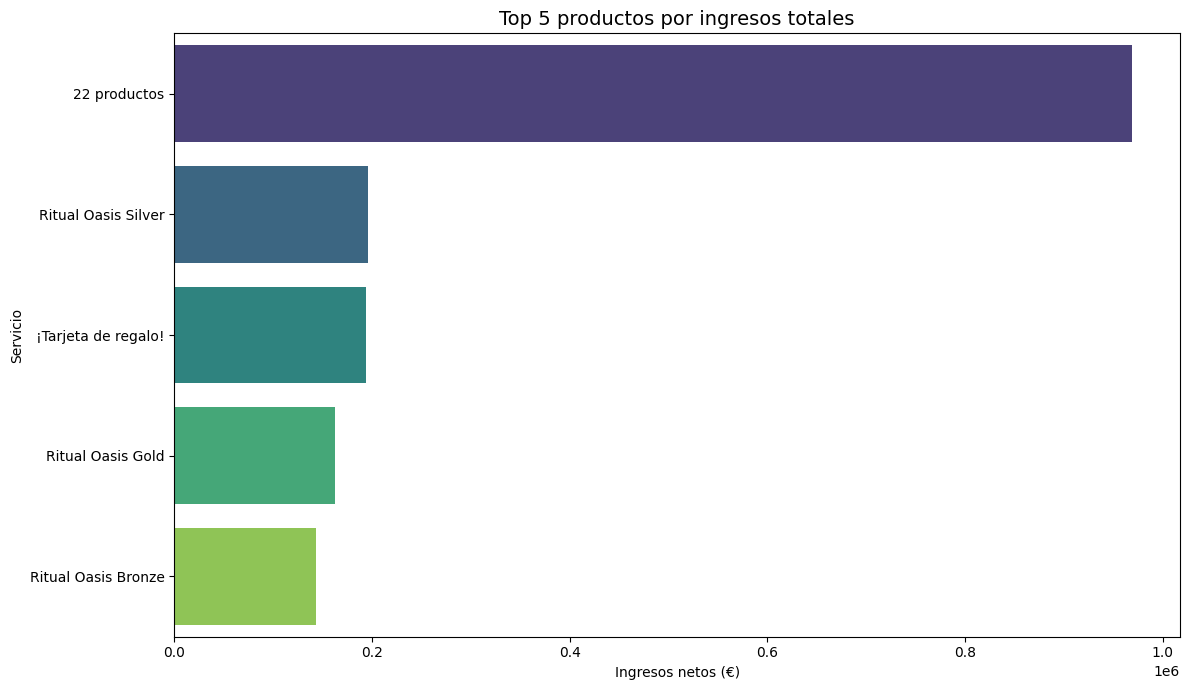

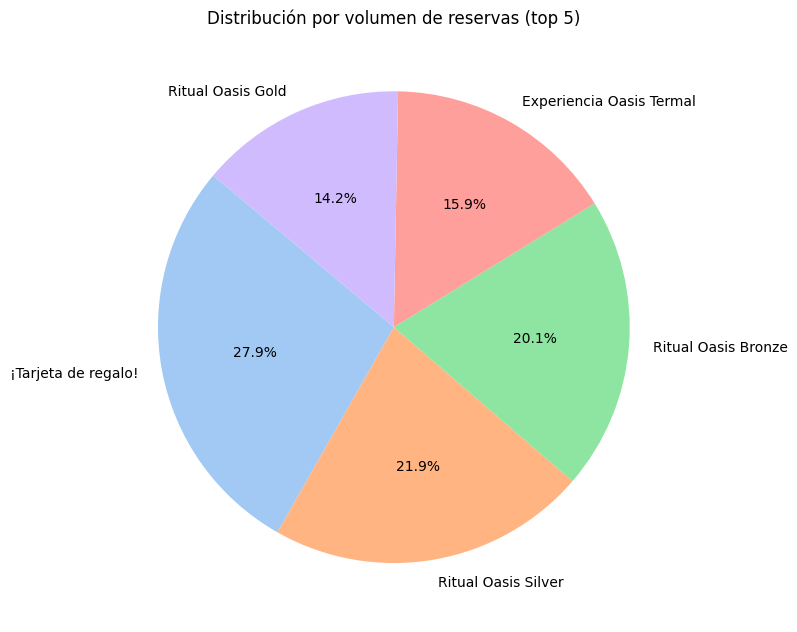

In [1]:
# Imports y utilidades centralizadas
import sys, os
sys.path.insert(0, '../utils')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from funciones import (limpiar_nombres_columnas, limpiar_moneda,
                       parsear_mes_es, anonimizar)

# --- Carga de datos y limpieza básica ---
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)
df_ventas = limpiar_nombres_columnas(df_ventas)
df_ventas['neto'] = df_ventas['neto'].apply(limpiar_moneda)

# --- Contexto inicial: top productos por ingresos y por volumen ---
productos_top = (df_ventas.groupby('producto')['neto']
                          .agg(['sum', 'count'])
                          .sort_values(by='sum', ascending=False))

# Gráfico 1 — Top 5 productos por ingresos totales
plt.figure(figsize=(12, 7))
sns.barplot(x=productos_top['sum'].head(5),
            y=productos_top.index[:5],
            palette='viridis', hue=productos_top.index[:5], legend=False)
plt.title('Top 5 productos por ingresos totales', fontsize=14)
plt.xlabel('Ingresos netos (€)')
plt.ylabel('Servicio')
plt.tight_layout()
plt.savefig('../img/03_producto_estrella_ingresos.png', dpi=200)
plt.show()
plt.close()

# Gráfico 2 — Distribución por volumen de reservas
plt.figure(figsize=(8, 8))
df_ventas['producto'].value_counts().head(5).plot(
    kind='pie', autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('pastel'))
plt.title('Distribución por volumen de reservas (top 5)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../img/03_producto_volumen.png', dpi=200)
plt.show()
plt.close()

In [2]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas = anonimizar(df_ventas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'cliente_id', 'cp_area']


## Verificación de H3 — Producto líder mensual

**Hipótesis:** existe un producto líder mensual (*top-of-mind*) que captura la mayor parte de las reservas en cada mes.

**Criterio de verificación:**
1. Para cada mes del periodo (mayo-2024 → abril-2026), identificar el producto con mayor volumen de reservas.
2. Medir su **cuota de mercado mensual** (% del total del mes) para evaluar si "captura la mayor parte" o solo es el más frecuente.
3. Detectar **estacionalidad de producto** (¿siempre lidera el mismo o cambia con el calendario?).

In [3]:
# Parseamos mes_del_pago a fecha cronológica
# (las filas spurias tipo "24 meses" se descartan al ser no parseables)
df_ventas['mes_dt'] = parsear_mes_es(df_ventas['mes_del_pago'])

# --- Producto líder por mes (volumen de reservas) ---
conteo = (df_ventas.dropna(subset=['mes_dt'])
                   .groupby([df_ventas['mes_dt'].dt.to_period('M'), 'producto'])
                   .size().reset_index(name='reservas'))

lider_mes = (conteo.sort_values(['mes_dt', 'reservas'], ascending=[True, False])
                   .groupby('mes_dt').head(1).reset_index(drop=True))

# Cuota de mercado del líder = % sobre el total del mes
total_mes = (conteo.groupby('mes_dt')['reservas'].sum()
                   .reset_index(name='total_mes'))
lider_mes = lider_mes.merge(total_mes, on='mes_dt')
lider_mes['cuota_pct'] = (lider_mes['reservas'] / lider_mes['total_mes'] * 100).round(1)
lider_mes['mes_dt']    = lider_mes['mes_dt'].astype(str)

print("=== Producto líder por mes (cuota = % de reservas del mes) ===")
print(lider_mes[['mes_dt', 'producto', 'reservas', 'total_mes', 'cuota_pct']]
      .to_string(index=False))
print(f"\nCuota media del líder: {lider_mes['cuota_pct'].mean():.1f}%")
print(f"Cuota máxima: {lider_mes['cuota_pct'].max():.1f}% "
      f"({lider_mes.loc[lider_mes['cuota_pct'].idxmax(), 'mes_dt']})")
print(f"Cuota mínima: {lider_mes['cuota_pct'].min():.1f}% "
      f"({lider_mes.loc[lider_mes['cuota_pct'].idxmin(), 'mes_dt']})")

=== Producto líder por mes (cuota = % de reservas del mes) ===
 mes_dt                 producto  reservas  total_mes  cuota_pct
2024-05      Ritual Oasis Bronze        26        109       23.9
2024-06      ¡Tarjeta de regalo!        54        168       32.1
2024-07      Ritual Oasis Silver        40        157       25.5
2024-08      Ritual Oasis Silver        66        203       32.5
2024-09      Ritual Oasis Bronze        63        248       25.4
2024-10      Ritual Oasis Silver        77        289       26.6
2024-11      ¡Tarjeta de regalo!        61        278       21.9
2024-12      ¡Tarjeta de regalo!       208        403       51.6
2025-01      ¡Tarjeta de regalo!       201        558       36.0
2025-02      Ritual Oasis Silver        81        420       19.3
2025-03      Ritual Oasis Silver        71        338       21.0
2025-04      Ritual Oasis Silver        67        322       20.8
2025-05      Ritual Oasis Bronze        72        371       19.4
2025-06      Ritual Oasis B

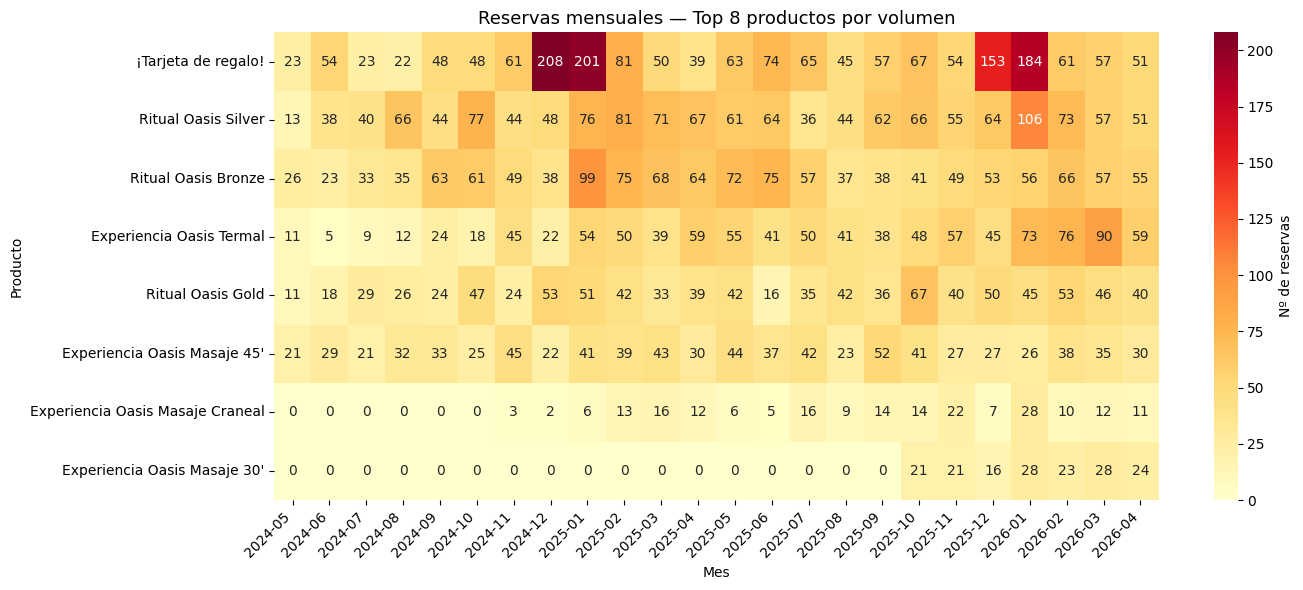

In [4]:
# GRÁFICO 3 — Heatmap mes × producto (top 8 por volumen total)
TOP_N = 8
top_productos = df_ventas['producto'].value_counts().head(TOP_N).index.tolist()

pivot = (conteo[conteo['producto'].isin(top_productos)]
         .pivot(index='producto', columns='mes_dt', values='reservas')
         .reindex(top_productos)         # filas: orden por volumen total
         .fillna(0).astype(int))
pivot.columns = pivot.columns.astype(str)  # YYYY-MM en formato string

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Nº de reservas'})
plt.title(f'Reservas mensuales — Top {TOP_N} productos por volumen', fontsize=13)
plt.xlabel('Mes')
plt.ylabel('Producto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../img/03_producto_heatmap_mensual.png', dpi=200)
plt.show()

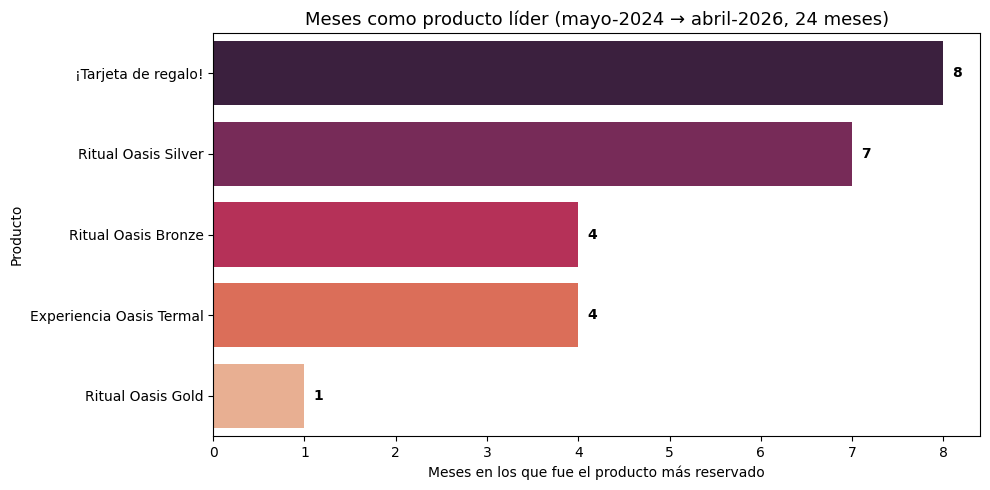


Productos diferentes que lideraron al menos un mes: 5

Detalle:
producto
¡Tarjeta de regalo!         8
Ritual Oasis Silver         7
Ritual Oasis Bronze         4
Experiencia Oasis Termal    4
Ritual Oasis Gold           1


In [5]:
# GRÁFICO 4 — ¿Cuántos meses lideró cada producto en estos 24 meses?
meses_lider = lider_mes['producto'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=meses_lider.values, y=meses_lider.index,
            palette='rocket', hue=meses_lider.index, legend=False)
plt.title('Meses como producto líder (mayo-2024 → abril-2026, 24 meses)',
          fontsize=13)
plt.xlabel('Meses en los que fue el producto más reservado')
plt.ylabel('Producto')
for i, v in enumerate(meses_lider.values):
    plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../img/03_producto_meses_como_lider.png', dpi=200)
plt.show()

# También mostramos la lista completa para referencia
print("\nProductos diferentes que lideraron al menos un mes:",
      lider_mes['producto'].nunique())
print("\nDetalle:")
print(meses_lider.to_string())

### Veredicto H3 — **MATIZADA**

**Resumen cuantitativo (24 meses analizados, mayo-2024 → abril-2026):**

| Métrica | Valor |
|---|---|
| Productos diferentes que lideraron algún mes | **5** de 23 |
| Cuota media del líder mensual | **~24 %** |
| Cuota máxima (diciembre 2024) | **51,6 %** — *Tarjeta de regalo* |
| Cuota mínima | **~16 %** |

**Interpretación:**

1. **Sí existe rotación clara del líder mensual** entre 5 productos: *Tarjeta de regalo* (8 meses), *Ritual Oasis Silver* (7), *Ritual Oasis Bronze* (4), *Experiencia Oasis Termal* (4) y *Ritual Oasis Gold* (1). No hay un único "top-of-mind" estable.
2. **La parte de "captura la mayor parte de las reservas" se REFUTA** en sentido estricto: salvo diciembre (efecto regalo navideño, 51,6 %), el líder mensual solo concentra ~16-35 % de las reservas del mes. La oferta está fragmentada.
3. **Patrón estacional fuerte y accionable:**
   - **Noviembre-enero** → *Tarjeta de regalo* domina (campañas Black Friday, Navidad, Reyes).
   - **Resto del año** → se reparten los rituales (*Silver*, *Bronze*, *Gold*) y la *Experiencia Oasis Termal*, que emerge con fuerza en los últimos 4 meses del periodo.

**Implicación de negocio:** la estrategia de marketing no debe asumir un producto estrella único, sino **rotar la comunicación según el calendario**: regalos en Q4-enero, rituales premium en primavera y experiencia termal como producto creciente para reforzar a partir de otoño-2025.